In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [16]:
df1 = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]

In [17]:
eval1=[]
from sklearn.cluster import KMeans
for i in range(1,10):
    model=KMeans(n_clusters=i, init='k-means++')
    model.fit(df)
    eval1.append(model.inertia_)

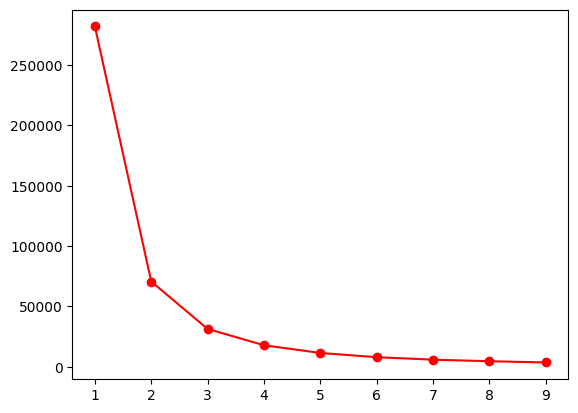

In [18]:
plt.plot(range(1,10),eval1,color='red',marker='o')

In [32]:
kmeans=KMeans(n_clusters=3,init='k-means++')
Y=kmeans.fit_predict(df)

In [33]:
df1['Y'] = Y

In [34]:
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1
146,6.3,2.5,5.0,1.9,1
147,6.5,3.0,5.2,2.0,1
148,6.2,3.4,5.4,2.3,1


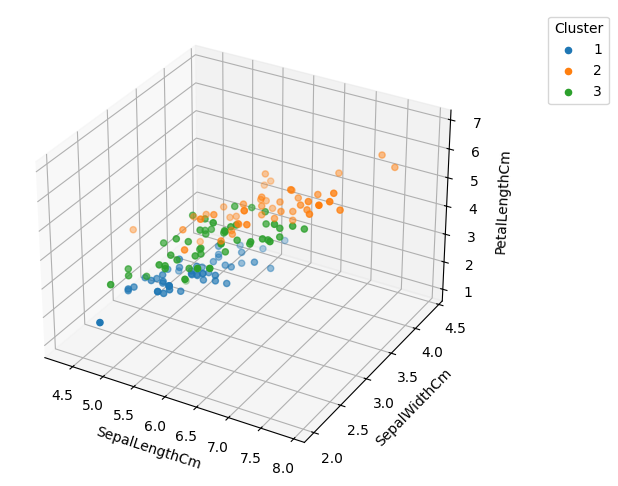

In [35]:

from mpl_toolkits.mplot3d import Axes3D

import numpy as np

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster separately
for cluster in sorted(df1['Y'].unique()):
    subset = df1[df1['Y'] == cluster]

    ax.scatter(
        subset['SepalLengthCm'],
        subset['SepalWidthCm'],
        subset['PetalLengthCm'],
        label=f'{cluster+1}'
    )

ax.set_xlabel('SepalLengthCm')
ax.set_ylabel('SepalWidthCm')
ax.set_zlabel('PetalLengthCm')

ax.legend(title='Cluster',
    bbox_to_anchor=(1.15, 1),
    loc='upper left'
         )
plt.show()